In [693]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Data Inspection

In [694]:
df=pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

In [695]:
df.head(24)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
5,NaN,291.72,0.0,0.0,1,Clear,sky is clear,2012-10-02 14:00:00,5181
6,NaN,293.17,0.0,0.0,1,Clear,sky is clear,2012-10-02 15:00:00,5584
7,NaN,293.86,0.0,0.0,1,Clear,sky is clear,2012-10-02 16:00:00,6015
8,NaN,294.14,0.0,0.0,20,Clouds,few clouds,2012-10-02 17:00:00,5791
9,NaN,293.10,0.0,0.0,20,Clouds,few clouds,2012-10-02 18:00:00,4770


In [696]:
df.tail(24)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
48180,NaN,280.07,0.00,0.0,90,Clouds,overcast clouds,2018-09-30 02:00:00,696
48181,NaN,280.08,0.00,0.0,90,Clouds,overcast clouds,2018-09-30 03:00:00,364
48182,NaN,279.88,0.00,0.0,90,Clouds,overcast clouds,2018-09-30 04:00:00,335
48183,NaN,279.96,0.00,0.0,90,Clouds,overcast clouds,2018-09-30 05:00:00,444
48184,NaN,280.17,0.00,0.0,90,Clouds,overcast clouds,2018-09-30 06:00:00,802
48185,NaN,280.16,0.00,0.0,90,Clouds,overcast clouds,2018-09-30 07:00:00,1175
48186,NaN,280.28,0.00,0.0,90,Clouds,overcast clouds,2018-09-30 08:00:00,2002
48187,NaN,280.62,0.00,0.0,90,Clouds,overcast clouds,2018-09-30 09:00:00,2882
48188,NaN,281.38,0.00,0.0,75,Clouds,broken clouds,2018-09-30 10:00:00,3701
48189,NaN,282.18,0.00,0.0,90,Clouds,overcast clouds,2018-09-30 11:00:00,4049


In [697]:
df.shape

(48204, 9)

In [698]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume'],
      dtype='object')

In [699]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [700]:
#count the missing values
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

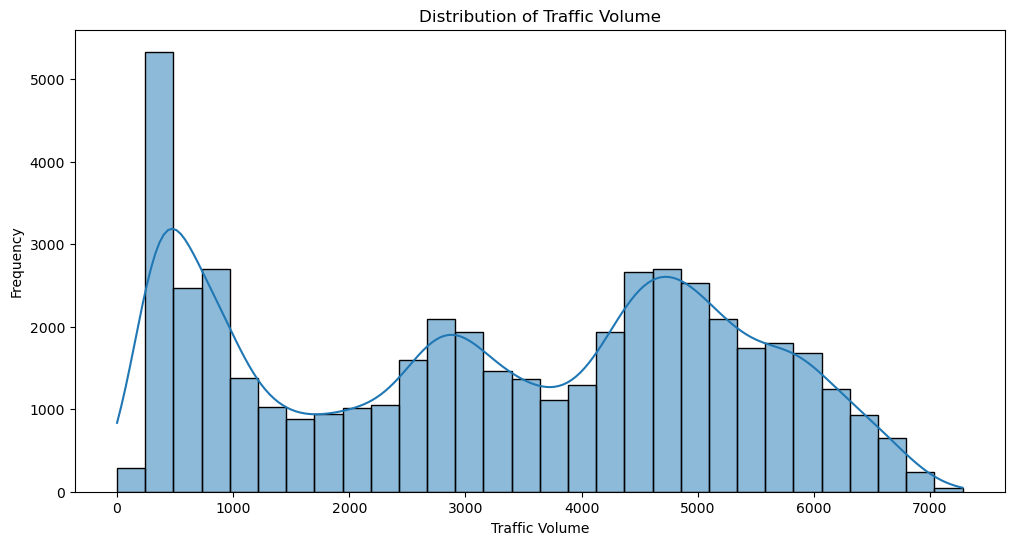

In [701]:
#plot the traffic volume 
plt.figure(figsize=(12,6))
sns.histplot(df['traffic_volume'], bins=30, kde=True)
plt.title('Distribution of Traffic Volume')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')
plt.show()

In [702]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [703]:
df['date_time'] = pd.to_datetime(df['date_time'])

In [704]:
# time skeleton
skeleton = pd.date_range(start = df['date_time'].min(), end = df['date_time'].max(), freq='h')
len(skeleton)

52551

In [705]:
# merging skeleton with original data to identify missing timestamps
skeleton_df = pd.DataFrame(skeleton, columns = ['date_time'])

In [706]:
df_full = pd.merge(skeleton_df, df, on = 'date_time', how = 'left')
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60180 entries, 0 to 60179
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date_time            60180 non-null  datetime64[ns]
 1   holiday              61 non-null     object        
 2   temp                 48204 non-null  float64       
 3   rain_1h              48204 non-null  float64       
 4   snow_1h              48204 non-null  float64       
 5   clouds_all           48204 non-null  float64       
 6   weather_main         48204 non-null  object        
 7   weather_description  48204 non-null  object        
 8   traffic_volume       48204 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(3)
memory usage: 4.1+ MB


In [707]:
# Calculate fraction of missing data for each year-month
missing_heatmap_data = df_full.copy()
missing_heatmap_data['year'] = missing_heatmap_data['date_time'].dt.year
missing_heatmap_data['month'] = missing_heatmap_data['date_time'].dt.month
missing_heatmap_data['is_missing'] = missing_heatmap_data['traffic_volume'].isna()

missing_heatmap_data = (
    missing_heatmap_data
    .groupby(['year', 'month'], as_index=False)
    ['is_missing']
    .mean()
    .assign(missing_pct=lambda x: round(x['is_missing'] * 100, 1))
    [['year', 'month', 'missing_pct']]
)

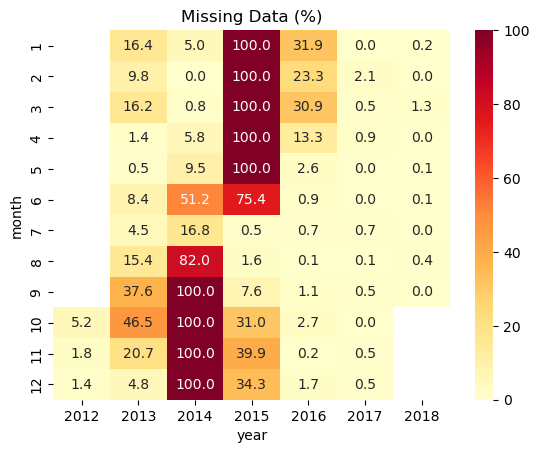

In [708]:
sns.heatmap(missing_heatmap_data.pivot_table(index='month', columns='year', values='missing_pct'), 
            annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Missing Data (%)')
plt.show()

### Data Cleaning

In [709]:
#convert temperature from Kelvin to Celsius as integer
df['temp_celsius']=df['temp'] - 273.15
df['temp_celsius']=df['temp_celsius'].astype(int)
#rename the temp column to temp_kelvin
df.rename(columns={'temp':'temp_kelvin'}, inplace=True)
df[['temp_kelvin','temp_celsius']].head()

,temp_kelvin,temp_celsius
0,288.28,15
1,289.36,16
2,289.58,16
3,290.13,16
4,291.14,17


In [710]:
df['year']=pd.to_datetime(df['date_time']).dt.year

In [711]:
#take the data from 2016 to 2018
df_filtered=df[(df['year']>=2017)]
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18554 entries, 29650 to 48203
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              22 non-null     object        
 1   temp_kelvin          18554 non-null  float64       
 2   rain_1h              18554 non-null  float64       
 3   snow_1h              18554 non-null  float64       
 4   clouds_all           18554 non-null  int64         
 5   weather_main         18554 non-null  object        
 6   weather_description  18554 non-null  object        
 7   date_time            18554 non-null  datetime64[ns]
 8   traffic_volume       18554 non-null  int64         
 9   temp_celsius         18554 non-null  int64         
 10  year                 18554 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(3), object(3)
memory usage: 1.6+ MB


In [712]:
#drop temp kelvin
df_filtered.drop(columns=['temp_kelvin'], inplace=True)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\2101275420.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.drop(columns=['temp_kelvin'], inplace=True)


In [713]:
df_filtered.head()

,holiday,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,temp_celsius,year
29650,NaN,0.0,0.0,75,Clouds,broken clouds,2017-01-01 00:00:00,1848,-3,2017
29651,NaN,0.0,0.0,1,Clear,sky is clear,2017-01-01 01:00:00,1806,-3,2017
29652,NaN,0.0,0.0,1,Clear,sky is clear,2017-01-01 02:00:00,1211,-3,2017
29653,NaN,0.0,0.0,40,Clouds,scattered clouds,2017-01-01 03:00:00,794,-3,2017
29654,NaN,0.0,0.0,1,Clear,sky is clear,2017-01-01 04:00:00,500,-3,2017


In [714]:
#convert holiday column to 0 and 1
df['holiday'] = df['holiday'].notna().astype(int)

In [715]:
df_filtered['holiday'] = df_filtered['holiday'].notna().astype(int)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\1068725835.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['holiday'] = df_filtered['holiday'].notna().astype(int)


In [716]:
# 1. Extract date only (remove the hour)
df_filtered['date_only'] = df_filtered['date_time'].dt.date

# 2. Find which dates have at least one holiday hour
holiday_dates = df_filtered.loc[df_filtered['holiday'] == 1, 'date_only'].unique()

# 3. Mark every hour of those dates as holiday
df_filtered['is_holiday'] = df_filtered['date_only'].isin(holiday_dates).astype(int)


C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\3303989928.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['date_only'] = df_filtered['date_time'].dt.date
C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\3303989928.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['is_holiday'] = df_filtered['date_only'].isin(holiday_dates).astype(int)


In [717]:
#show rows with is_holiday 1
df_filtered[df_filtered['is_holiday'] == 1].head(24)

,holiday,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,temp_celsius,year,date_only,is_holiday
29674,1,0.0,0.0,90,Snow,light snow,2017-01-02 00:00:00,798,-2,2017,2017-01-02,1
29675,0,0.0,0.0,90,Snow,light snow,2017-01-02 01:00:00,522,-2,2017,2017-01-02,1
29676,0,0.0,0.0,90,Snow,light snow,2017-01-02 02:00:00,457,-2,2017,2017-01-02,1
29677,0,0.0,0.0,90,Snow,light snow,2017-01-02 03:00:00,363,-2,2017,2017-01-02,1
29678,0,0.0,0.0,90,Clouds,overcast clouds,2017-01-02 04:00:00,508,-2,2017,2017-01-02,1
29679,0,0.0,0.0,90,Clouds,overcast clouds,2017-01-02 05:00:00,849,-2,2017,2017-01-02,1
29680,0,0.0,0.0,90,Clouds,overcast clouds,2017-01-02 06:00:00,1562,-2,2017,2017-01-02,1
29681,0,0.0,0.0,90,Clouds,overcast clouds,2017-01-02 07:00:00,1792,-2,2017,2017-01-02,1
29682,0,0.0,0.0,90,Clouds,overcast clouds,2017-01-02 08:00:00,2014,-2,2017,2017-01-02,1
29683,0,0.0,0.0,90,Clouds,overcast clouds,2017-01-02 09:00:00,2401,-1,2017,2017-01-02,1


In [718]:
#make 2017-01-02 0 for is_holiday and 2017-01-01 is holiday 1
df_filtered.loc[df_filtered['date_only'] == pd.to_datetime('2017-01-02').date(), 'is_holiday'] = 0
df_filtered.loc[df_filtered['date_only'] == pd.to_datetime('2017-01-01').date(), 'is_holiday'] = 1

In [719]:
#drop holiday
df_filtered.drop(columns=['holiday','date_only'], inplace=True)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\543222963.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.drop(columns=['holiday','date_only'], inplace=True)


In [720]:
df_filtered['hour']=pd.to_datetime(df['date_time']).dt.hour
df_filtered['day_of_week']=pd.to_datetime(df['date_time']).dt.dayofweek
df_filtered['month']=pd.to_datetime(df['date_time']).dt.month

C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\341357382.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['hour']=pd.to_datetime(df['date_time']).dt.hour
C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\341357382.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['day_of_week']=pd.to_datetime(df['date_time']).dt.dayofweek
C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\341357382.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

In [721]:
df_filtered.head()

,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,temp_celsius,year,is_holiday,hour,day_of_week,month
29650,0.0,0.0,75,Clouds,broken clouds,2017-01-01 00:00:00,1848,-3,2017,1,0,6,1
29651,0.0,0.0,1,Clear,sky is clear,2017-01-01 01:00:00,1806,-3,2017,1,1,6,1
29652,0.0,0.0,1,Clear,sky is clear,2017-01-01 02:00:00,1211,-3,2017,1,2,6,1
29653,0.0,0.0,40,Clouds,scattered clouds,2017-01-01 03:00:00,794,-3,2017,1,3,6,1
29654,0.0,0.0,1,Clear,sky is clear,2017-01-01 04:00:00,500,-3,2017,1,4,6,1


In [722]:
df_filtered.head(29)

,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,temp_celsius,year,is_holiday,hour,day_of_week,month
29650,0.0,0.0,75,Clouds,broken clouds,2017-01-01 00:00:00,1848,-3,2017,1,0,6,1
29651,0.0,0.0,1,Clear,sky is clear,2017-01-01 01:00:00,1806,-3,2017,1,1,6,1
29652,0.0,0.0,1,Clear,sky is clear,2017-01-01 02:00:00,1211,-3,2017,1,2,6,1
29653,0.0,0.0,40,Clouds,scattered clouds,2017-01-01 03:00:00,794,-3,2017,1,3,6,1
29654,0.0,0.0,1,Clear,sky is clear,2017-01-01 04:00:00,500,-3,2017,1,4,6,1
29655,0.0,0.0,1,Clear,sky is clear,2017-01-01 05:00:00,513,-3,2017,1,5,6,1
29656,0.0,0.0,1,Clear,sky is clear,2017-01-01 06:00:00,821,-4,2017,1,6,6,1
29657,0.0,0.0,40,Clouds,scattered clouds,2017-01-01 07:00:00,950,-4,2017,1,7,6,1
29658,0.0,0.0,1,Clear,sky is clear,2017-01-01 08:00:00,1284,-5,2017,1,8,6,1
29659,0.0,0.0,20,Clouds,few clouds,2017-01-01 09:00:00,2279,-5,2017,1,9,6,1


In [723]:
#drop weather_description ,date_time columns
df_filtered.drop(columns=['weather_description','date_time'], inplace=True)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\3468233839.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.drop(columns=['weather_description','date_time'], inplace=True)


In [724]:
df_filtered.head()

,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,temp_celsius,year,is_holiday,hour,day_of_week,month
29650,0.0,0.0,75,Clouds,1848,-3,2017,1,0,6,1
29651,0.0,0.0,1,Clear,1806,-3,2017,1,1,6,1
29652,0.0,0.0,1,Clear,1211,-3,2017,1,2,6,1
29653,0.0,0.0,40,Clouds,794,-3,2017,1,3,6,1
29654,0.0,0.0,1,Clear,500,-3,2017,1,4,6,1


In [725]:
df_filtered['hour_sin'] = np.sin(2 * np.pi * df_filtered['hour'] / 24)
df_filtered['hour_cos'] = np.cos(2 * np.pi * df_filtered['hour'] / 24)
df_filtered['day_sin'] = np.sin(2 * np.pi * df_filtered['day_of_week'] / 7)
df_filtered['day_cos'] = np.cos(2 * np.pi * df_filtered['day_of_week'] / 7)
df_filtered.drop(columns=['hour'], inplace=True)
df_filtered.drop(columns=['day_of_week'], inplace=True)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\3716083436.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['hour_sin'] = np.sin(2 * np.pi * df_filtered['hour'] / 24)
C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\3716083436.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['hour_cos'] = np.cos(2 * np.pi * df_filtered['hour'] / 24)
C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\3716083436.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [726]:
df_filtered.drop(columns=['year'], inplace=True)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\2233783158.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.drop(columns=['year'], inplace=True)


In [727]:
df_filtered.head()

,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,temp_celsius,is_holiday,month,hour_sin,hour_cos,day_sin,day_cos
29650,0.0,0.0,75,Clouds,1848,-3,1,1,0.000000,1.000000,-0.781831,0.62349
29651,0.0,0.0,1,Clear,1806,-3,1,1,0.258819,0.965926,-0.781831,0.62349
29652,0.0,0.0,1,Clear,1211,-3,1,1,0.500000,0.866025,-0.781831,0.62349
29653,0.0,0.0,40,Clouds,794,-3,1,1,0.707107,0.707107,-0.781831,0.62349
29654,0.0,0.0,1,Clear,500,-3,1,1,0.866025,0.500000,-0.781831,0.62349


In [728]:
#check unique values in weather_main
df_filtered['weather_main'].value_counts()

weather_main
Clear           5363
Clouds          5012
Mist            2470
Rain            2114
Snow            1100
Drizzle          904
Haze             620
Thunderstorm     537
Fog              431
Smoke              3
Name: count, dtype: int64

In [729]:
#rename weather_main to weather
df_filtered.rename(columns={'weather_main':'weather'}, inplace=True)
#map the values of weather to more general categories
weather_mapping = {
    'Clear': 'clear',
    'Clouds': 'cloudy',
    'Mist': 'foggy',
    'Haze': 'foggy',
    'Fog': 'foggy',
    'Rain': 'rainy',
    'Drizzle': 'rainy',
    'Thunderstorm': 'stormy',
    'Snow': 'snowy',
    'Smoke': 'foggy',
}
df_filtered['weather'] = df_filtered['weather'].map(weather_mapping)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\3904214044.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.rename(columns={'weather_main':'weather'}, inplace=True)
C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\3904214044.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['weather'] = df_filtered['weather'].map(weather_mapping)


In [730]:
# get dummy variables for weather_main
df_filtered = pd.get_dummies(df_filtered, columns=['weather'], drop_first=True)
df_filtered

,rain_1h,snow_1h,clouds_all,traffic_volume,temp_celsius,is_holiday,month,hour_sin,hour_cos,day_sin,day_cos,weather_cloudy,weather_foggy,weather_rainy,weather_snowy,weather_stormy
29650,0.0,0.0,75,1848,-3,1,1,0.000000,1.000000,-0.781831,0.62349,True,False,False,False,False
29651,0.0,0.0,1,1806,-3,1,1,0.258819,0.965926,-0.781831,0.62349,False,False,False,False,False
29652,0.0,0.0,1,1211,-3,1,1,0.500000,0.866025,-0.781831,0.62349,False,False,False,False,False
29653,0.0,0.0,40,794,-3,1,1,0.707107,0.707107,-0.781831,0.62349,True,False,False,False,False
29654,0.0,0.0,1,500,-3,1,1,0.866025,0.500000,-0.781831,0.62349,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,0.0,0.0,75,3543,10,0,9,-0.965926,0.258819,-0.781831,0.62349,True,False,False,False,False
48200,0.0,0.0,90,2781,9,0,9,-0.866025,0.500000,-0.781831,0.62349,True,False,False,False,False
48201,0.0,0.0,90,2159,9,0,9,-0.707107,0.707107,-0.781831,0.62349,False,False,False,False,True
48202,0.0,0.0,90,1450,8,0,9,-0.500000,0.866025,-0.781831,0.62349,True,False,False,False,False


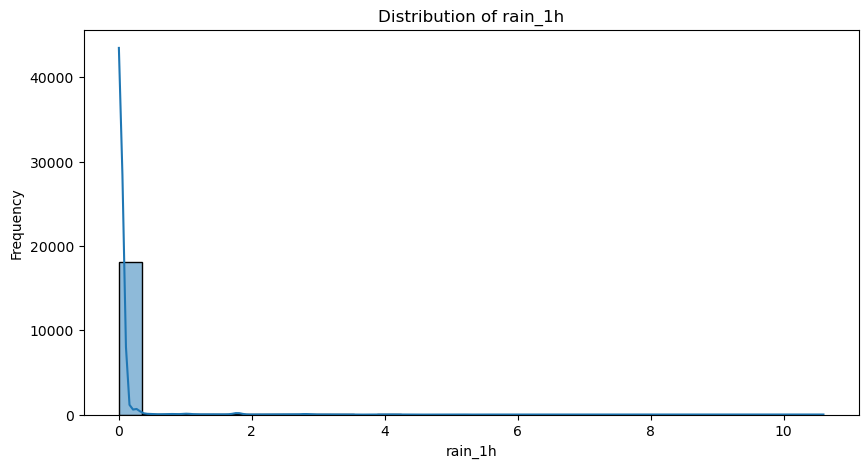

In [731]:
#distribution of rain_1h 
plt.figure(figsize=(10,5))
sns.histplot(df_filtered['rain_1h'], bins=30, kde=True)
plt.title('Distribution of rain_1h')
plt.xlabel('rain_1h')
plt.ylabel('Frequency')
plt.show()

In [732]:

print(df_filtered.shape)
df_filtered['rain_1h'].value_counts()


(18554, 16)


rain_1h
0.00    17841
0.25      269
1.78       68
1.02       29
2.79       17
        ...  
0.43        2
0.71        2
0.64        2
2.96        1
0.66        1
Name: count, Length: 87, dtype: int64

In [733]:
#all is zeros
#df_filtered.drop(columns=['rain_1h'], inplace=True)

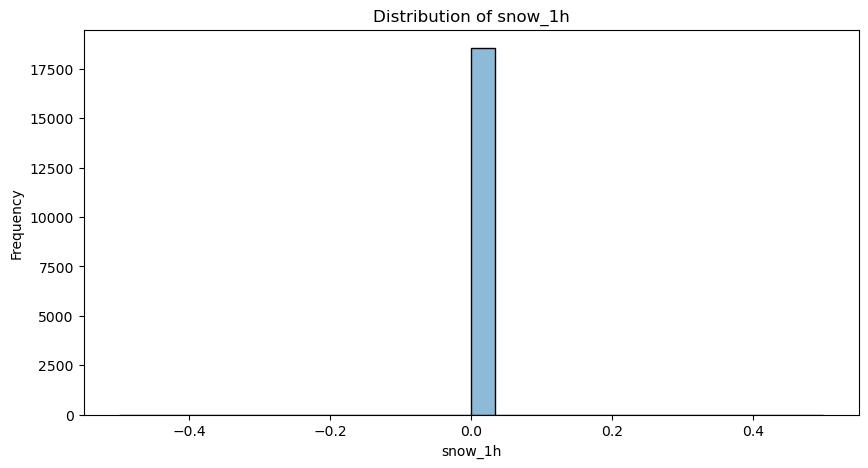

In [734]:
#distribution of snow_1h 
plt.figure(figsize=(10,5))
sns.histplot(df_filtered['snow_1h'], bins=30, kde=True)
plt.title('Distribution of snow_1h')
plt.xlabel('snow_1h')
plt.ylabel('Frequency')
plt.show()

In [735]:
print(df_filtered.shape)
df_filtered['snow_1h'].value_counts()

(18554, 16)


snow_1h
0.0    18554
Name: count, dtype: int64

In [736]:
#all is zeros
df_filtered.drop(columns=['snow_1h'], inplace=True)

In [737]:
df_filtered.head()

,rain_1h,clouds_all,traffic_volume,temp_celsius,is_holiday,month,hour_sin,hour_cos,day_sin,day_cos,weather_cloudy,weather_foggy,weather_rainy,weather_snowy,weather_stormy
29650,0.0,75,1848,-3,1,1,0.000000,1.000000,-0.781831,0.62349,True,False,False,False,False
29651,0.0,1,1806,-3,1,1,0.258819,0.965926,-0.781831,0.62349,False,False,False,False,False
29652,0.0,1,1211,-3,1,1,0.500000,0.866025,-0.781831,0.62349,False,False,False,False,False
29653,0.0,40,794,-3,1,1,0.707107,0.707107,-0.781831,0.62349,True,False,False,False,False
29654,0.0,1,500,-3,1,1,0.866025,0.500000,-0.781831,0.62349,False,False,False,False,False


In [738]:
#rename holiday to is_holiday
df_filtered.rename(columns={'holiday':'is_holiday'}, inplace=True)
df_filtered['is_holiday'].value_counts()

is_holiday
0    18031
1      523
Name: count, dtype: int64

In [739]:
df_filtered.dtypes

rain_1h           float64
clouds_all          int64
traffic_volume      int64
temp_celsius        int64
is_holiday          int64
month               int32
hour_sin          float64
hour_cos          float64
day_sin           float64
day_cos           float64
weather_cloudy       bool
weather_foggy        bool
weather_rainy        bool
weather_snowy        bool
weather_stormy       bool
dtype: object

In [740]:

cols=['rain_1h','month','temp_celsius','is_holiday','hour_sin','hour_cos','day_sin','day_cos','weather_cloudy','weather_foggy','weather_rainy','weather_snowy','weather_stormy']
X = df_filtered[cols].apply(lambda col: col.astype(int) if col.dtype == 'bool' else col)
X = sm.add_constant(X)         # Add constant for statsmodels

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

           feature       VIF
0            const  6.769424
1          rain_1h  1.046646
2            month  1.180559
3     temp_celsius  1.377906
4       is_holiday  1.020388
5         hour_sin  1.078902
6         hour_cos  1.033523
7          day_sin  1.003777
8          day_cos  1.023732
9   weather_cloudy  1.495105
10   weather_foggy  1.367536
11   weather_rainy  1.387135
12   weather_snowy  1.204765
13  weather_stormy  1.113858


In [741]:
#clouds_all is redundant with weather_cloudy and also month isn't important here
df_final=df_filtered.drop(columns=['clouds_all','month'])

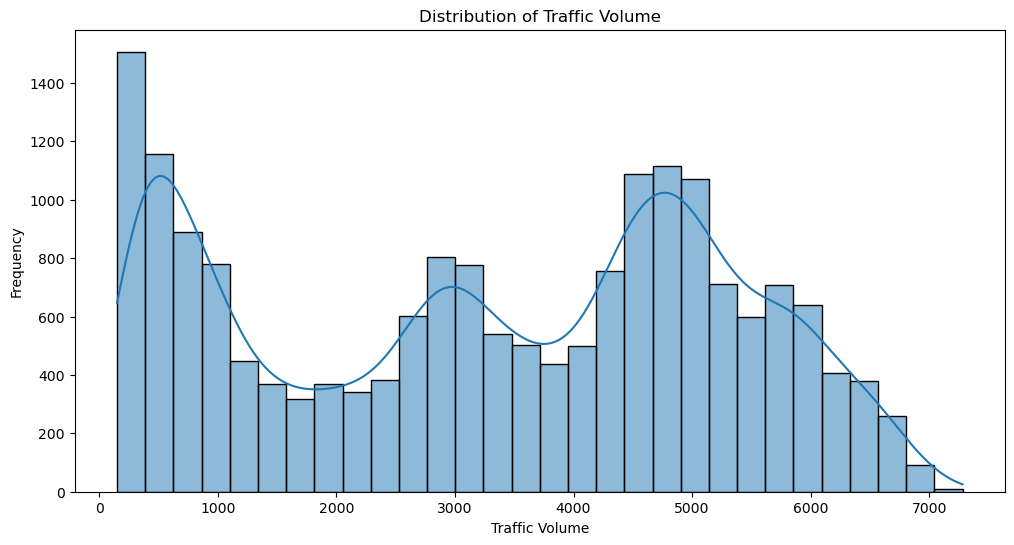

In [742]:
#plot the traffic volume 
plt.figure(figsize=(12,6))
sns.histplot(df_final['traffic_volume'], bins=30, kde=True)
plt.title('Distribution of Traffic Volume')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')
plt.show()

### Possion GLM

In [743]:
#predictors
predictors =[col for col in df_final.columns if col != 'traffic_volume']
X = df_final[predictors]
y = df_final['traffic_volume']
X = X.apply(lambda col: col.astype(int) if col.dtype == 'bool' else pd.to_numeric(col, errors='coerce'))

X = sm.add_constant(X)
#split the data into training and testing sets 80 20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples  : {len(y_train):,}")
print(f"Test samples      : {len(y_test):,}")

Training samples  : 14,843
Test samples      : 3,711


In [744]:
# Fit Poisson GLM
poisson_model = sm.GLM(y_train, X_train, family=sm.families.Poisson())
poisson_results = poisson_model.fit()

# View summary
print(poisson_results.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         traffic_volume   No. Observations:                14843
Model:                            GLM   Df Residuals:                    14830
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -4.3042e+06
Date:                Mon, 08 Dec 2025   Deviance:                   8.4655e+06
Time:                        17:58:02   Pearson chi2:                 8.57e+06
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              7.9691      0.000   2.63e

In [745]:
y_pred = poisson_results.predict(X_test)

In [746]:
# Overdispersion ratio
dispersion_pois = poisson_results.pearson_chi2  / poisson_results.df_resid
print("dispersion ratio:", dispersion_pois)

dispersion ratio: 577.6437085746908


In [747]:
aic_pois = poisson_results.aic
print("AIC:", aic_pois)

AIC: 8608350.678288803


In [748]:
mae_pois = mean_absolute_error(y_test, y_pred)
rmse_pois = np.sqrt(mean_squared_error(y_test, y_pred))
ll_pois = poisson_results.llf

In [749]:
X_null_train = sm.add_constant(np.ones(len(y_train)))
poisson_null = sm.GLM(y_train, X_null_train, family=sm.families.Poisson()).fit()
poisson_mcfadden_r2 = 1 - (poisson_results.llf / poisson_null.llf)
print("McFadden's R²:", poisson_mcfadden_r2)

McFadden's R²: 0.5925476337189878


In [750]:
X_null_test = sm.add_constant(np.ones(len(y_test)))

# Null model predictions
y_null_pred = poisson_null.predict(X_null_test)

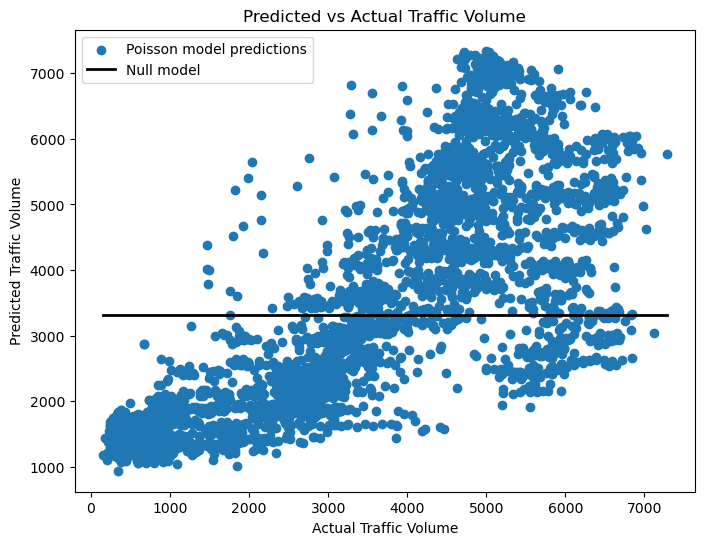

In [751]:
plt.figure(figsize=(8,6))

# Poisson model predictions
plt.scatter(y_test, y_pred,label='Poisson model predictions')

# Null model as horizontal line
plt.plot([y_test.min(), y_test.max()],
         [y_null_pred[0], y_null_pred[0]],  # constant value
         color='black', lw=2, label='Null model')



plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Predicted vs Actual Traffic Volume")
plt.legend()
plt.show()


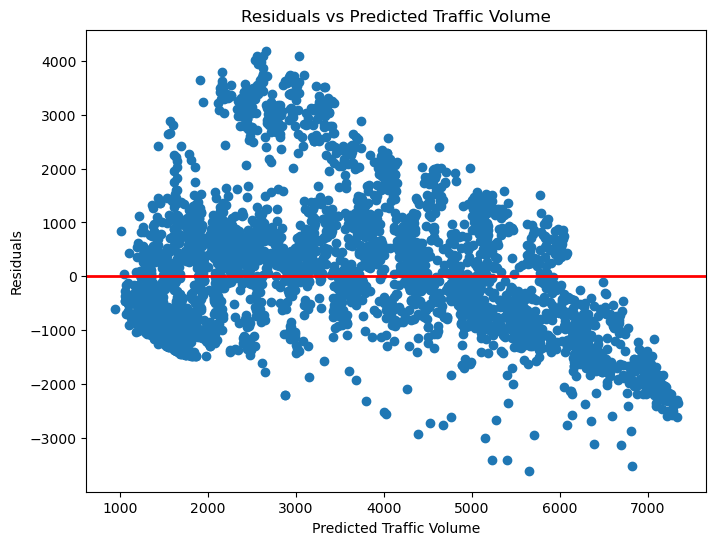

In [752]:
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', lw=2)  # horizontal line at 0
plt.xlabel("Predicted Traffic Volume")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Traffic Volume")
plt.show()

### NB GLM calculated alpha

In [753]:
mu_train = poisson_results.predict(X_train)
aux_dep = ((y_train - mu_train)**2 - mu_train) / mu_train
aux_res = sm.OLS(aux_dep, mu_train).fit()
alpha_est = aux_res.params[0]
print("Estimated alpha:", alpha_est)

Estimated alpha: 0.11550033066203788


C:\Users\ahmed\AppData\Local\Temp\ipykernel_31408\2780353681.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha_est = aux_res.params[0]


In [754]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

nb_model = sm.GLM(y_train, X_train_const,family=sm.families.NegativeBinomial(alpha=alpha_est)).fit()

# Summary
print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         traffic_volume   No. Observations:                14843
Model:                            GLM   Df Residuals:                    14830
Model Family:        NegativeBinomial   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.3260e+05
Date:                Mon, 08 Dec 2025   Deviance:                       38525.
Time:                        17:58:03   Pearson chi2:                 3.82e+04
No. Iterations:                    12   Pseudo R-squ. (CS):             0.9467
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              7.9443      0.006   1414.

In [755]:
# Predicted mean counts for test set
y_pred_nb = nb_model.predict(X_test_const)

In [756]:
aic_value_NB = nb_model.aic
print("AIC:", aic_value_NB)

AIC: 265233.53379686177


In [757]:
X_null_train = sm.add_constant(np.ones(len(y_train)))
nb_null = sm.GLM(y_train, X_null_train, family=sm.families.NegativeBinomial(alpha=alpha_est)).fit()

# McFadden R²
nb_mcfadden_r2 = 1 - (nb_model.llf / nb_null.llf)
print("NB GLM McFadden R²:", nb_mcfadden_r2)

NB GLM McFadden R²: 0.14097170478545562


In [758]:
# Overdispersion ratio
dispersion_nb = nb_model.pearson_chi2  / nb_model.df_resid
print("dispersion ratio:", dispersion_nb)

dispersion ratio: 2.5780412495178417


In [759]:
mae_nb = mean_absolute_error(y_test, y_pred_nb)
rmse_nb = np.sqrt(mean_squared_error(y_test, y_pred_nb))

In [760]:
X_null_test = sm.add_constant(np.ones(len(y_test)))

# Null model predictions
y_null_pred = nb_null.predict(X_null_test)

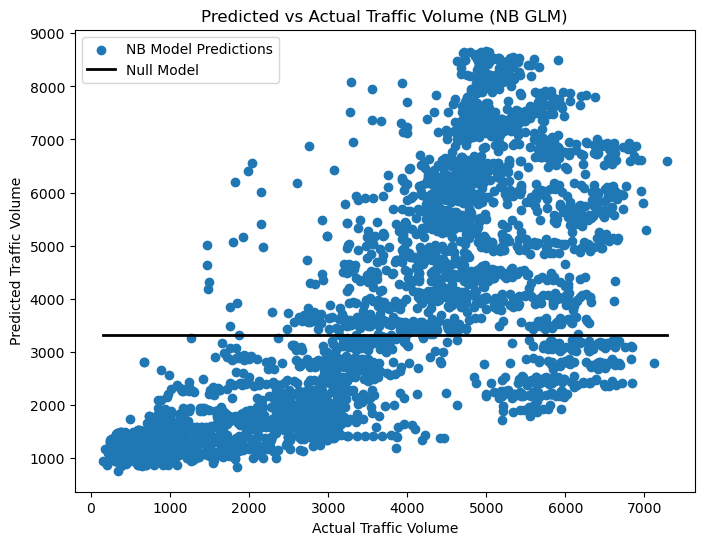

In [761]:
plt.figure(figsize=(8,6))

# NB model predictions
plt.scatter(y_test, y_pred_nb, label='NB Model Predictions')

# Null model as horizontal line (constant mean)
plt.plot([y_test.min(), y_test.max()],
         [y_null_pred[0], y_null_pred[0]],
         color='black', lw=2, label='Null Model')

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Predicted vs Actual Traffic Volume (NB GLM)")
plt.legend()
plt.show()


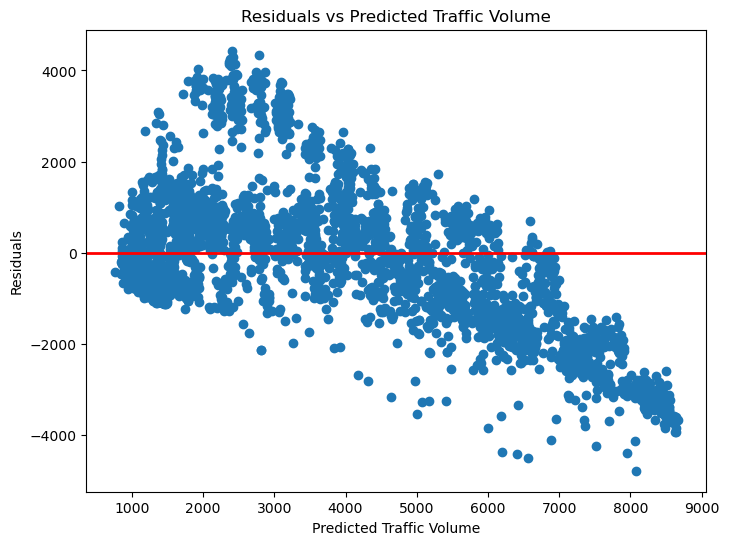

In [762]:
#draw residuals plot for negative binomial model
residuals = y_test - y_pred_nb
plt.figure(figsize=(8,6))
plt.scatter(y_pred_nb, residuals)
plt.axhline(0, color='red', lw=2)  # horizontal line at 0
plt.xlabel("Predicted Traffic Volume")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Traffic Volume")
plt.show()

In [763]:
summary = pd.DataFrame({
    "Metric": ["AIC", "Log-Likelihood", "McFadden R2", "Dispersion", "MAE", "RMSE"],
    "Poisson": [aic_pois, ll_pois, poisson_mcfadden_r2, dispersion_pois, mae_pois, rmse_pois],
    "NegBin":  [aic_value_NB,  nb_model.llf,  nb_mcfadden_r2,  dispersion_nb,  mae_nb,  rmse_nb]
})

summary

,Metric,Poisson,NegBin
0,AIC,8.608351e+06,265233.533797
1,Log-Likelihood,-4.304162e+06,-132603.766898
2,McFadden R2,5.925476e-01,0.140972
3,Dispersion,5.776437e+02,2.578041
4,MAE,9.969044e+02,1146.959854
5,RMSE,1.256648e+03,1485.842929


### NB GLM alpha =61.55

In [764]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

nb_model2 = sm.GLM(y_train, X_train_const,family=sm.families.NegativeBinomial(alpha=61.55)).fit()

# Summary
print(nb_model2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         traffic_volume   No. Observations:                14843
Model:                            GLM   Df Residuals:                    14830
Model Family:        NegativeBinomial   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.7782e+05
Date:                Mon, 08 Dec 2025   Deviance:                       72.821
Time:                        17:58:03   Pearson chi2:                     72.2
No. Iterations:                    10   Pseudo R-squ. (CS):           0.005509
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              7.9443      0.129     61.

In [765]:
# Predicted mean counts for test set
y_pred_nb_2 = nb_model2.predict(X_test_const)

In [766]:
aic_value_NB_2 = nb_model2.aic
print("AIC:", aic_value_NB_2)

AIC: 355662.26293385535


In [767]:
X_null_train = sm.add_constant(np.ones(len(y_train)))
nb_null_2 = sm.GLM(y_train, X_null_train, family=sm.families.NegativeBinomial(alpha=61.55)).fit()

# McFadden R²
nb_mcfadden_r2_2 = 1 - (nb_model2.llf / nb_null_2.llf)
print("NB GLM McFadden R²:", nb_mcfadden_r2)

NB GLM McFadden R²: 0.14097170478545562


In [768]:
# Overdispersion ratio
dispersion_nb_2 = nb_model2.pearson_chi2  / nb_model2.df_resid
print("dispersion ratio:", dispersion_nb)

dispersion ratio: 2.5780412495178417


In [769]:
mae_nb_2 = mean_absolute_error(y_test, y_pred_nb_2)
rmse_nb_2 = np.sqrt(mean_squared_error(y_test, y_pred_nb_2))

In [770]:
X_null_test = sm.add_constant(np.ones(len(y_test)))

# Null model predictions
y_null_pred = nb_null_2.predict(X_null_test)

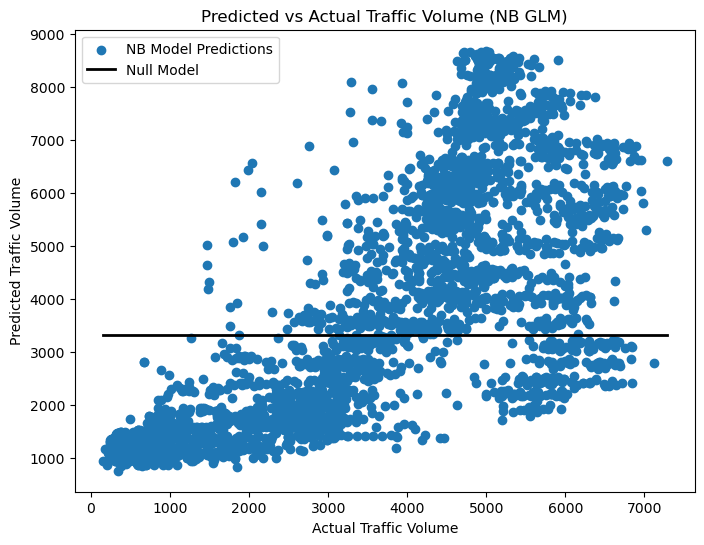

In [772]:
plt.figure(figsize=(8,6))

# NB model predictions
plt.scatter(y_test, y_pred_nb_2, label='NB Model Predictions')

# Null model as horizontal line (constant mean)
plt.plot([y_test.min(), y_test.max()],
         [y_null_pred[0], y_null_pred[0]],
         color='black', lw=2, label='Null Model')

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Predicted vs Actual Traffic Volume (NB GLM)")
plt.legend()
plt.show()

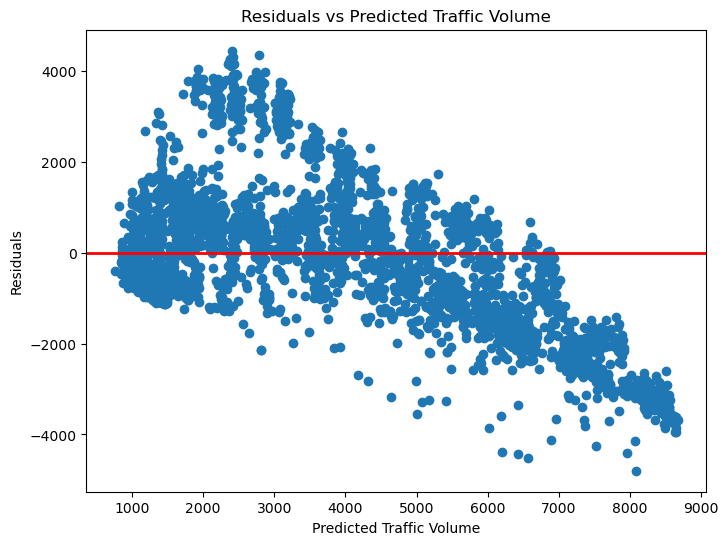

In [773]:
#draw residuals plot for negative binomial model
residuals = y_test - y_pred_nb_2
plt.figure(figsize=(8,6))
plt.scatter(y_pred_nb_2, residuals)
plt.axhline(0, color='red', lw=2)  # horizontal line at 0
plt.xlabel("Predicted Traffic Volume")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Traffic Volume")
plt.show()

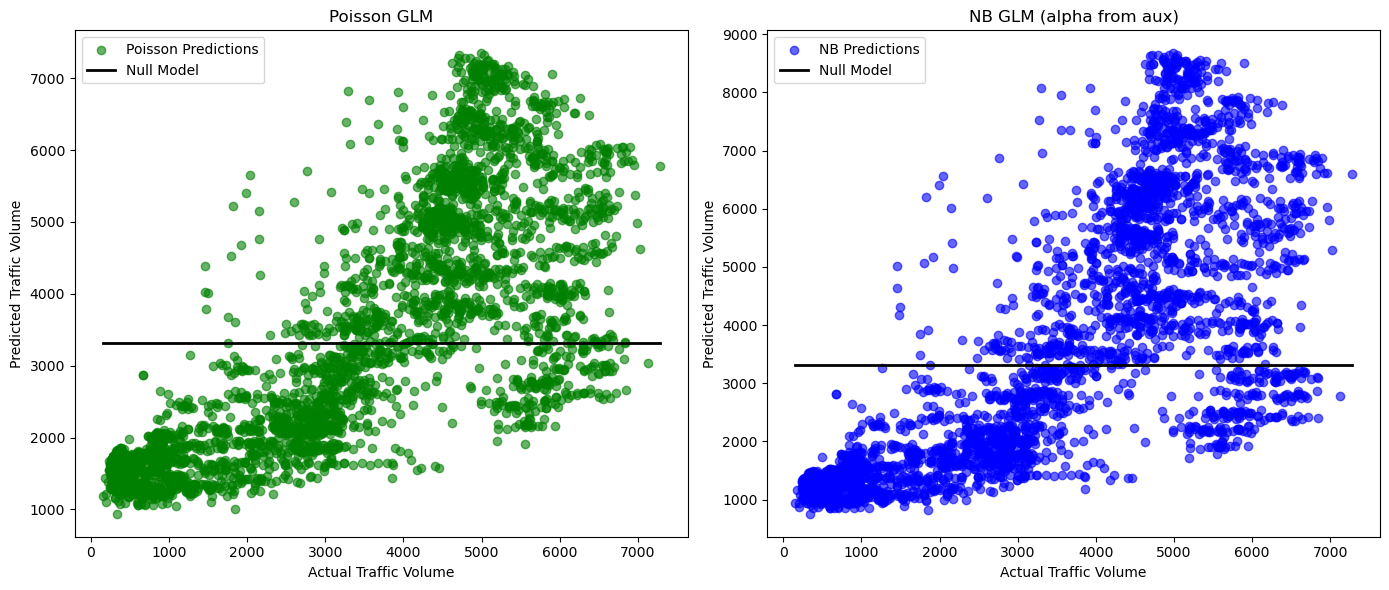

In [782]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# ---------------- Poisson Model ----------------
axes[0].scatter(y_test, y_pred, color='green', alpha=0.6, label='Poisson Predictions')
axes[0].plot([y_test.min(), y_test.max()],
             [y_null_pred[0], y_null_pred[0]],
             color='black', lw=2, label='Null Model')
axes[0].set_xlabel("Actual Traffic Volume")
axes[0].set_ylabel("Predicted Traffic Volume")
axes[0].set_title("Poisson GLM")
axes[0].legend()

# ---------------- NB Model 1 ----------------
axes[1].scatter(y_test, y_pred_nb, color='blue', alpha=0.6, label='NB Predictions')
axes[1].plot([y_test.min(), y_test.max()],
             [y_null_pred[0], y_null_pred[0]],
             color='black', lw=2, label='Null Model')
axes[1].set_xlabel("Actual Traffic Volume")
axes[1].set_ylabel("Predicted Traffic Volume")
axes[1].set_title("NB GLM (alpha from aux)")
axes[1].legend()



plt.tight_layout()
plt.show()

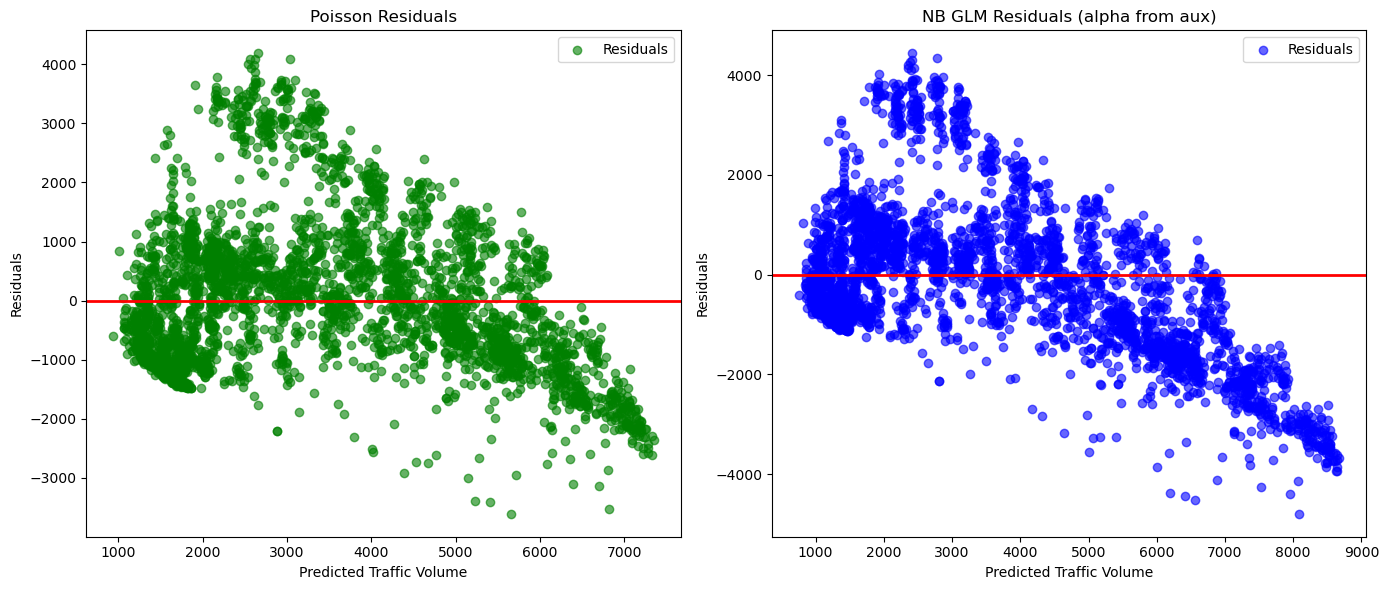

In [783]:


fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# ---------------- Poisson residuals ----------------
residuals_poisson = y_test - y_pred
axes[0].scatter(y_pred, residuals_poisson, alpha=0.6, color='green', label='Residuals')
axes[0].axhline(0, color='red', lw=2)
axes[0].set_xlabel("Predicted Traffic Volume")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Poisson Residuals")
axes[0].legend()

# ---------------- NB Model 1 residuals ----------------
residuals_nb = y_test - y_pred_nb
axes[1].scatter(y_pred_nb, residuals_nb, alpha=0.6, color='blue', label='Residuals')
axes[1].axhline(0, color='red', lw=2)
axes[1].set_xlabel("Predicted Traffic Volume")
axes[1].set_ylabel("Residuals")
axes[1].set_title("NB GLM Residuals (alpha from aux)")
axes[1].legend()



plt.tight_layout()
plt.show()


In [776]:
summary = pd.DataFrame({
    "Metric": ["AIC", "Log-Likelihood", "McFadden R2", "Dispersion", "MAE", "RMSE"],
    "Poisson": [aic_pois, ll_pois, poisson_mcfadden_r2, dispersion_pois, mae_pois, rmse_pois],
    "NegBin calculated alpha":  [aic_value_NB,  nb_model.llf,  nb_mcfadden_r2,  dispersion_nb,  mae_nb,  rmse_nb],
    "NegBin alpha = 61.55":  [aic_value_NB_2,  nb_model2.llf,  nb_mcfadden_r2_2,  dispersion_nb_2,  mae_nb_2,  rmse_nb_2]
})
summary

,Metric,Poisson,NegBin calculated alpha,NegBin alpha = 61.55
0,AIC,8.608351e+06,265233.533797,355662.262934
1,Log-Likelihood,-4.304162e+06,-132603.766898,-177818.131467
2,McFadden R2,5.925476e-01,0.140972,0.000231
3,Dispersion,5.776437e+02,2.578041,0.004867
4,MAE,9.969044e+02,1146.959854,1148.005102
5,RMSE,1.256648e+03,1485.842929,1487.525500
